In [1]:
from cil.optimisation.algorithms import FISTA
from cil.optimisation.operators import BlurringOperator
from cil.optimisation.functions import LeastSquares, TotalVariation
from cil.utilities import dataexample, noise
from cil.utilities.display import show2D
from cil.optimisation.functions import BM3DFunction
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as PSNR
from skimage.metrics import structural_similarity as SSIM
import matplotlib.pyplot as plt

In [2]:
# Load data
data = dataexample.SHAPES.get()

# Extract image geometry
ig = data.geometry

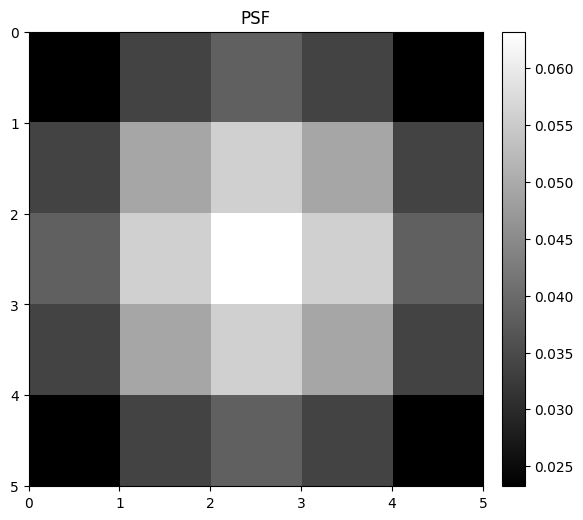

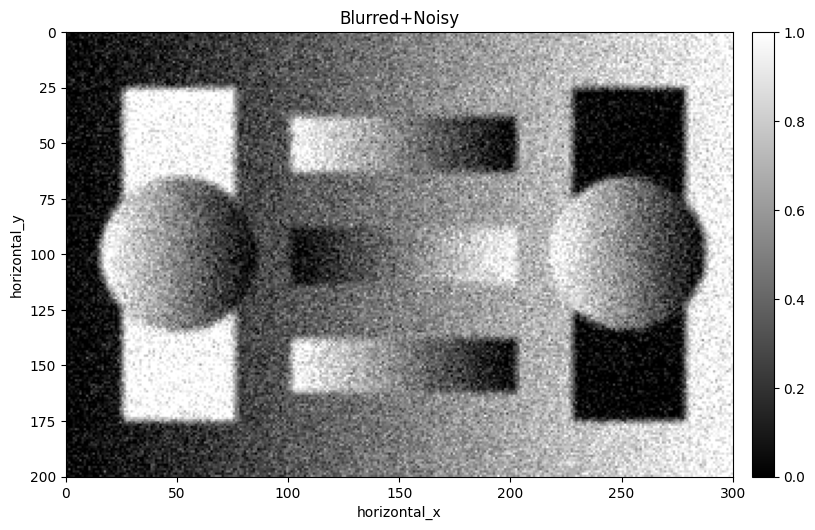

In [3]:
# Parameters for point spread function PSF (size and std)
ks          = 5
ksigma      = 2

# Create 1D PSF and 2D as outer product, then normalise.
w           = np.exp(-np.arange(-(ks-1)/2,(ks-1)/2+1)**2/(2*ksigma**2))
w.shape     = (ks,1)
PSF         = w*np.transpose(w)
PSF         = PSF/(PSF**2).sum()
PSF         = PSF/PSF.sum()

# Display PSF as image
show2D(PSF, origin="upper", title="PSF", size=(10,10))

# Create blurring operator and apply to clean image to produce blurred and display.
BOP = BlurringOperator(PSF,ig)
blurred_noisy = noise.gaussian(BOP.direct(data), seed = 10, var = 0.01)

# Show blurred and noisy image
show2D(blurred_noisy, origin="upper", title="Blurred+Noisy", size=(10,10));

### Fista TV

In [4]:
alpha = 0.05
G = alpha * TotalVariation(max_iteration=10)
F = LeastSquares(BOP, blurred_noisy)
fista_tv = FISTA(initial=ig.allocate(0), f=F, g=G, update_objective_interval=5)
fista_tv.run(20)

  0%|          | 0/20 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### Plug  and Play (PnP) BM3D/FISTA

In [5]:
sigma = 0.1 # np.sqrt(var)
G = BM3DFunction(sigma)
F = LeastSquares(BOP, blurred_noisy)
fista_pnp = FISTA(initial=ig.allocate(0), f=F, g=G, update_objective_interval=5)
fista_pnp.run(20)

  0%|          | 0/20 [00:00<?, ?it/s]

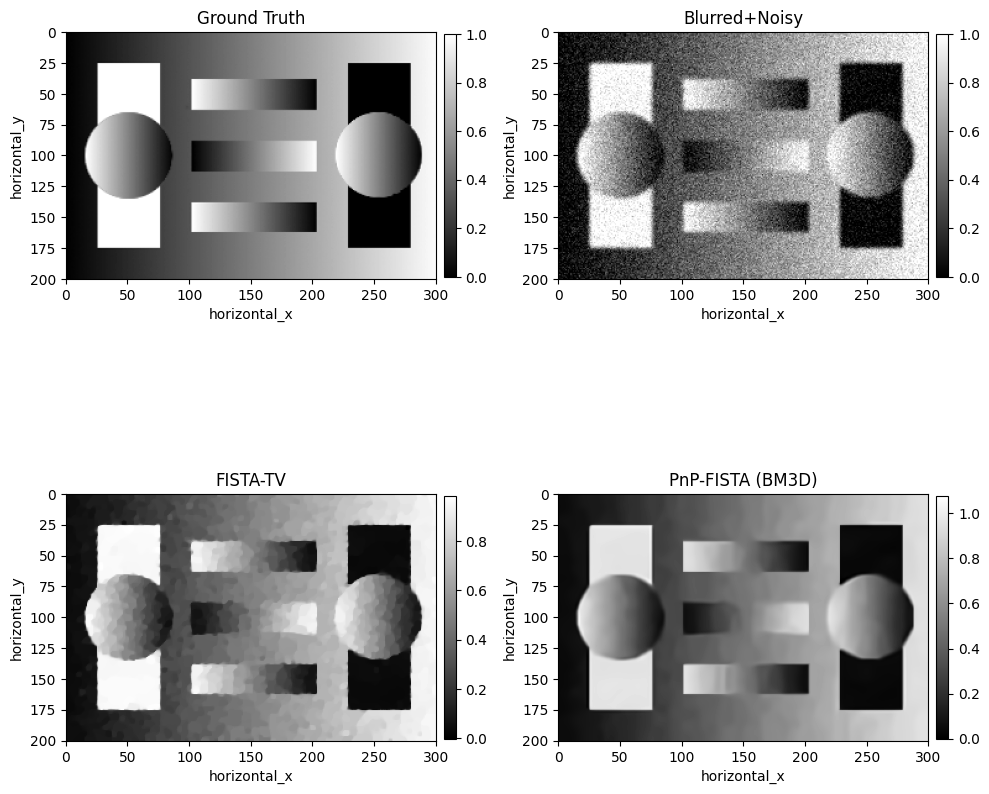

In [6]:
show2D([data, blurred_noisy, 
        fista_tv.solution, fista_pnp.solution], 
       origin="upper", 
       title=["Ground Truth", "Blurred+Noisy", "FISTA-TV", "PnP-FISTA (BM3D)"], size=(10,10));

In [7]:
sigmas = [0.01, 0.05, 0.07, 0.1, 0.2, 0.5]
denoised_bm3d = {}
for sigma in sigmas:
    G = BM3DFunction(sigma)
    F = LeastSquares(BOP, blurred_noisy)
    fista_pnp = FISTA(initial=ig.allocate(0), f=F, g=G, update_objective_interval=5)
    fista_pnp.run(20)
    psnr_val = PSNR(data.array, fista_pnp.solution.array, data_range=1.0)
    ssim_val = SSIM(data.array, fista_pnp.solution.array, data_range=1.0)
    denoised_bm3d[sigma] = [fista_pnp, psnr_val, ssim_val]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

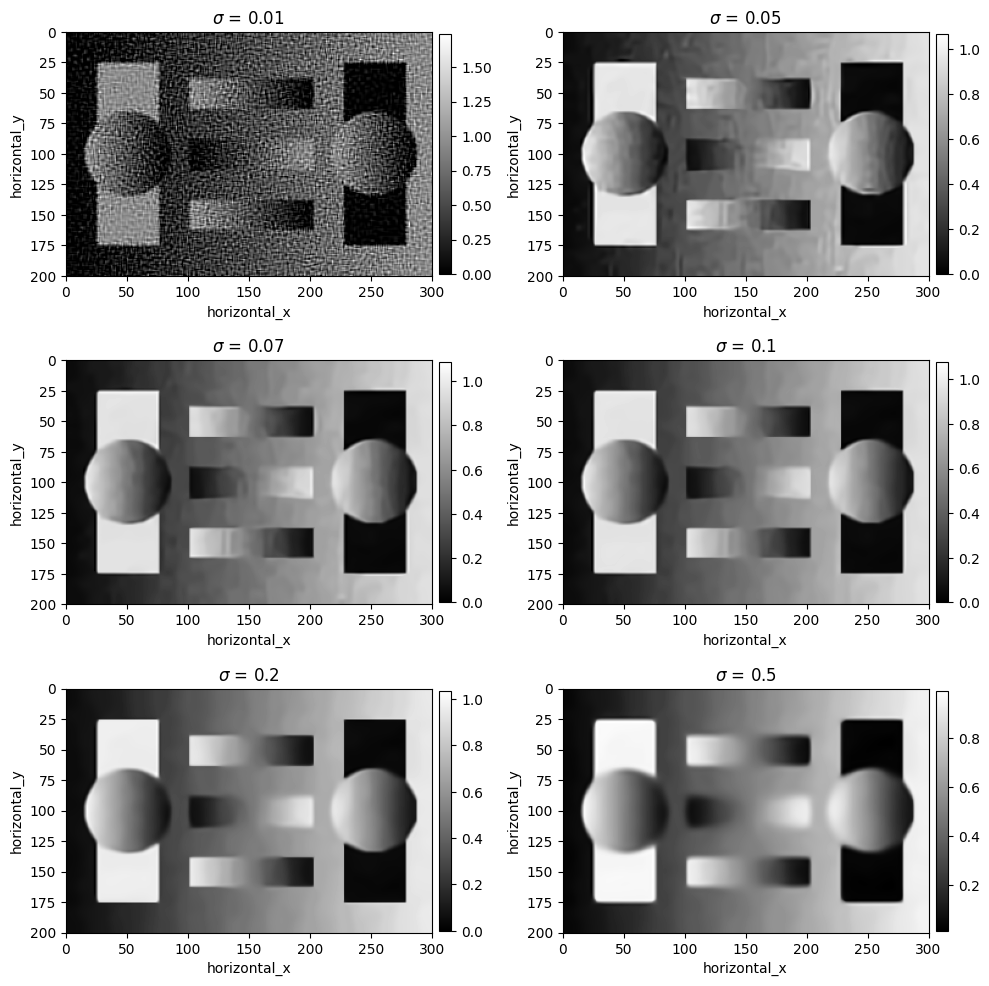

In [9]:
titles = [rf"$\sigma$ = {s}" for s in sigmas]
imgs     = [denoised_bm3d[s][0].solution for s in sigmas]  
show2D(imgs, origin="upper", title=titles, size=(10,10))

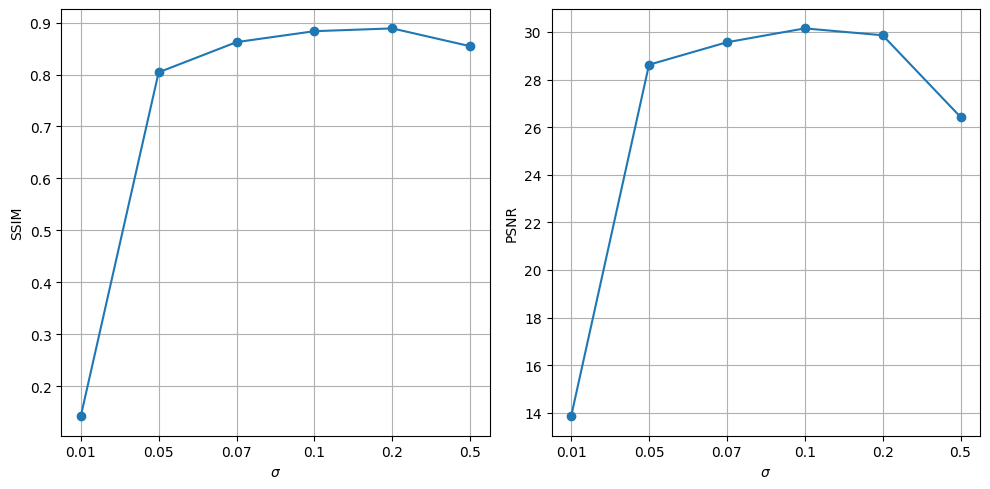

In [10]:

ssim_val = [denoised_bm3d[s][2] for s in sigmas]
psnr_val = [denoised_bm3d[s][1] for s in sigmas]


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

x = np.arange(len(sigmas)) 

ax[0].plot(x, ssim_val, marker='o')
ax[0].set_ylabel("SSIM")
ax[0].set_xlabel(r"$\sigma$")
ax[0].set_xticks(x)
ax[0].set_xticklabels(sigmas)
ax[0].grid()

ax[1].plot(x, psnr_val, marker='o')
ax[1].set_ylabel("PSNR")
ax[1].set_xlabel(r"$\sigma$")
ax[1].set_xticks(x)
ax[1].set_xticklabels(sigmas)
ax[1].grid()

plt.tight_layout()
plt.show()
